<a href="https://colab.research.google.com/github/MMathisLab/Leaf_Ant_Analysis/blob/main/Sharing__ant_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐜 Analysis, post-DLC

- custom code written by Mackenzie Mathis. For any questions, please reach out: mackenzie.mathis@epfl.ch

- this assumes you have the `h5` file outputs of the video analysis


In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

# Set up a bunch of useful functions!

- please see the docstrings for more details.

In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Ants_Mackenzie_2024')  # Add the directory containing your module
import utils_ant_analysis
from utils_ant_analysis import *

# ANALYSIS:
- Load the DLC video h5 DATA
- set keypoint name

In [ ]:
# DATA:

#short demo for code dev:
#file_path = '/content/drive/MyDrive/Ants_Mackenzie_2024/short_demo_antDLC_dlcrnetms5_AntsFeb11shuffle1_100000_el.h5'

#the real deal:
#video 1:
file_path = '/content/drive/MyDrive/Ants_Mackenzie_2024/Ants-mackenzie-2024-02-11/videos/ant_video_1DLC_dlcrnetms5_AntsFeb11shuffle1_100000_el.h5'

#video 2:
#file_path = '/content/drive/MyDrive/Ants_Mackenzie_2024/Ants-mackenzie-2024-02-11/videos/ant_video_2DLC_dlcrnetms5_AntsFeb11shuffle1_100000_el.h5'

#video 3:
#file_path = '/content/drive/MyDrive/Ants_Mackenzie_2024/Ants-mackenzie-2024-02-11/videos/ant_video_3DLC_dlcrnetms5_AntsFeb11shuffle1_100000_el.h5'

#video 4:
#file_path = '/content/drive/MyDrive/Ants_Mackenzie_2024/Ants-mackenzie-2024-02-11/videos/ant_video_4DLC_dlcrnetms5_AntsFeb11shuffle1_100000_el.h5'

#video 5:
#file_path = '/content/drive/MyDrive/Ants_Mackenzie_2024/Ants-mackenzie-2024-02-11/videos/ant_video_5DLC_dlcrnetms5_AntsFeb11shuffle1_100000_el.h5'

tracked_keypoint_name = "ant_head"

In [ ]:
df,bodyparts, scorer = load_data(file_path,smooth=True)

In [ ]:
df.head(3)

scorer      DLC_dlcrnetms5_AntsFeb11shuffle1_100000                         \
individuals                                   ant_1                          
bodyparts                                  ant_head                          
coords                                            x           y likelihood   
0                                        115.770167  514.850000      0.982   
1                                        115.761667  514.741000      0.951   
2                                        115.756000  514.668333      0.961   

scorer                                                               \
individuals                                                           
bodyparts   ant_midbody                         ant_end               
coords                x           y likelihood        x           y   
0            107.877167  524.352000      0.849  108.009  531.799667   
1            107.857667  524.303000      0.414  107.889  531.624667   
2            107.844667  524.270333      0.541  107.809  531.508000   

scorer                            ...                                  \
individuals            drug_ant2  ...          single                   
bodyparts               ant_head  ... drug_pupa_pile1 drug_pupa_pile2   
coords      likelihood         x  ...      likelihood               x   
0                0.813  764.1695  ...             1.0      747.643167   
1                0.504  764.1660  ...             1.0      747.643667   
2                0.591  766.5800  ...             1.0      747.645333   

scorer                                                                     \
individuals                                                                 
bodyparts                          drug_pupa_pile3                          
coords                y likelihood               x           y likelihood   
0            223.373833        1.0      691.765667  284.648667        1.0   
1            223.374333        1.0      691.767667  284.656667        1.0   
2            223.375000        1.0      691.768667  284.659000        1.0   

scorer                                              
individuals                                         
bodyparts   drug_pupa_pile4                         
coords                    x           y likelihood  
0                754.147667  288.885333        1.0  
1                754.147667  288.886333        1.0  
2                754.147333  288.886667        1.0  

[3 rows x 108 columns]

# We start by looking at ANTS and how much time it spends in the leaf ROI in chamber 1 (left side):
- modified march 10th, now we want to use any data from ant1 and ant2; because we know that ant1 and ant2 stay within the larger ROI zone, and there could be DLC-tracking errors (jumps), we safely assume any ant inside the ROI is a specific ant, i.e., ANT1 is always in the left chamber!

In [ ]:
# FOR OUTSIDE THE LEAF ZONE< LEFT CHAMBER-- this is more accurate to account for occulsions:
corner_names = ['corner1', 'corner2', 'boundary1', 'boundary2']
corner_order = ['corner1', 'corner2',  'boundary2', 'boundary1','corner1'] # Ensure correct order to close the rectangle

# FOR WITHIN THE LEAF ZONE, LEFT CHAMBER:
#corner_names = ['boundary1', 'boundary2', 'corner3', 'corner4']
#corner_order = ['boundary1', 'boundary2',  'corner4', 'corner3','boundary1'] # Ensure correct order to close the rectangle

In [ ]:
# Define the list of ant identifiers you want to check
ants = ['ant_1', 'drug_ant2']

# Call the function to compute the time inside the rectangle for each ant
times_inside_rectangle = compute_time_inside_dynamic_rectangle(df, scorer, ants, corner_names, tracked_keypoint_name, frame_rate=10)

total_frames = len(df)
print(total_frames)
frame_rate = 10  # fps, change this if your video has a different frame rate

# Calculate the total length of the video in seconds
total_length_seconds = total_frames / frame_rate


# Display the total length of the video
print(total_length_seconds, "total length in sec of video")

# Initialize a variable to hold the sum of the times
total_time_inside = 0

# Loop through each ant and accumulate the time inside the ROI
for ant, time_inside in times_inside_rectangle.items():
    print(f"{ant} spends {time_inside} seconds inside the ROI")
    total_time_inside += time_inside

# Display the sum of the times of the ants
print(f"Total time spent by 'super-ANT' inside the left ROI: {np.round(total_time_inside)} seconds")

# in case of errors in overlap, we will check and remove:
overlapping_frame_count = count_frames_ants_in_roi_simultaneously(df, scorer, ants, corner_names, tracked_keypoint_name, frame_rate=10)
print(f"Ant_1 and Ant_2 are present within the ROI at the same time in {overlapping_frame_count} frames.")


68784
6878.4 total length in sec of video
ant_1 spends 1804.0 seconds inside the ROI
drug_ant2 spends 237.6 seconds inside the ROI
Total time spent by 'super-ANT' inside the left ROI: 2042.0 seconds
Ant_1 and Ant_2 are present within the ROI at the same time in 450 frames.


## Result #1: time in leaf chamber 1 (left side):

In [ ]:
true_time = total_time_inside - (overlapping_frame_count/10)
#print(total_time_inside)
print(f"Considering double counting, the ANT is within the ROI {np.round(true_time)} seconds. The fraction of time is {np.round((true_time/total_length_seconds)*100, 2)} percent")

Considering double counting, the ANT is within the ROI 1997.0 seconds. The fraction of time is 29.03 percent


# make some plots

-  Here is the plot where anything within the ROI is assumed for be for ant1
- We post-modify the tracker due to we know the ant must be within a spatial bound.

In [ ]:
# Assuming compute_time_inside_dynamic_rectangle and is_inside_rectangle functions are already defined
# Assuming df, scorer, corner_names are already defined and loaded


# Use the function to extract corner points over each frame
corner_points_over_frames = extract_corner_points_over_frames(df, scorer, corner_names)

# To display a small sample of the extracted points for verification
{corner: corner_points_over_frames[corner][:5] for corner in corner_points_over_frames}

# Extract corner points for the entire DataFrame
corner_points = extract_corner_points_over_frames(df, scorer,corner_names)

# Determine the bounds of the rectangle from corner points
xmin = min(min(point[0] for point in corner_points[corner]) for corner in corner_points)
xmax = max(max(point[0] for point in corner_points[corner]) for corner in corner_points)
ymin = min(min(point[1] for point in corner_points[corner]) for corner in corner_points)
ymax = max(max(point[1] for point in corner_points[corner]) for corner in corner_points)

# Extract a sample of corner points for plotting purposes
corner_sample = {corner: corner_points_over_frames[corner][:10] for corner in corner_points_over_frames}

# Get the time each ant spent inside the rectangle
times_inside_rectangle = compute_time_inside_dynamic_rectangle(df, scorer, ants, corner_names,tracked_keypoint_name, frame_rate=10)

# Extract the positions of ants and filter the positions where each ant is inside the rectangle
ant_positions_inside = {ant: {'x': [], 'y': []} for ant in ants}

for i in range(len(df)):
    for ant in ants:
        ant_x_col = (scorer, ant, tracked_keypoint_name, 'x')
        ant_y_col = (scorer, ant, tracked_keypoint_name, 'y')
        ant_x = df[ant_x_col].iloc[i]
        ant_y = df[ant_y_col].iloc[i]
        if is_inside_rectangle(ant_x, ant_y, xmin, xmax, ymin, ymax):
            ant_positions_inside[ant]['x'].append(ant_x)
            ant_positions_inside[ant]['y'].append(ant_y)

## Heatmap for paper plots:

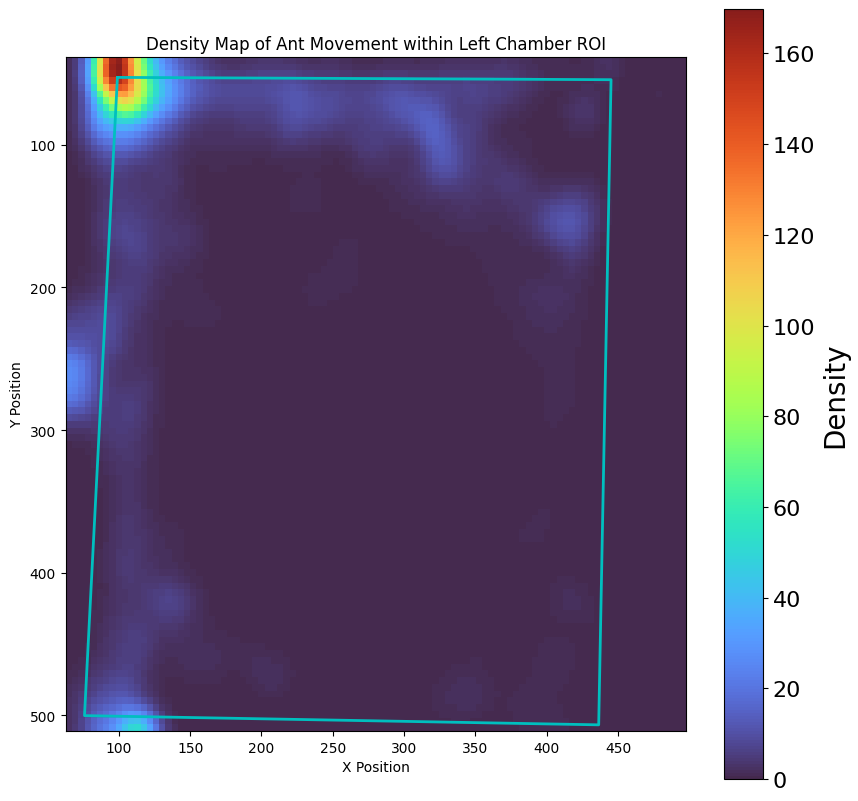

In [ ]:
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

# Assuming the 'extract_corner_points_over_frames' function is already defined
# Assuming df, scorer, corner_names, corner_order are already defined and loaded

# Extract corner points for the entire DataFrame
corner_points = extract_corner_points_over_frames(df, scorer, corner_names)

# Extract positions for both ants and filter out NaN values
all_ants_x, all_ants_y = [], []

for ant in ants:
    ant_full_x = df[(scorer, ant, tracked_keypoint_name, 'x')].values
    ant_full_y = df[(scorer, ant, tracked_keypoint_name, 'y')].values
    valid_indices = ~np.isnan(ant_full_x) & ~np.isnan(ant_full_y)
    all_ants_x.extend(ant_full_x[valid_indices])
    all_ants_y.extend(ant_full_y[valid_indices])

# Create a combined 2D histogram for the "super ant"
grid_size = 100  # Adjust for resolution
heatmap, xedges, yedges = np.histogram2d(all_ants_x, all_ants_y, bins=grid_size, range=[[xmin, xmax], [ymin, ymax]])

# Apply Gaussian smoothing
heatmap_smoothed = gaussian_filter(heatmap, sigma=2)

# Plotting the density map with an adjusted aspect ratio
plt.figure(figsize=(19.2, 10.8))  # This will create a figure with the aspect ratio of the video
plt.imshow(heatmap_smoothed.T, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='turbo', aspect='equal', alpha=0.9)

# Overlay the rectangle defined by the corner points
rectangle_x = [corner_points[corner][0][0] for corner in corner_order]
rectangle_y = [corner_points[corner][0][1] for corner in corner_order]
plt.plot(rectangle_x, rectangle_y, 'c-', linewidth=2)  # Cyan lines to define the rectangle

# Setting the title with placeholders
plot_title = "Density Map of Ant Movement within Left Chamber ROI"
plt.title(plot_title)
plt.xlabel('X Position')
plt.ylabel('Y Position')

cbar = plt.colorbar(label='Density')
cbar.ax.set_ylabel('Density', fontsize=20)  # Set the font size for the colorbar label
cbar.ax.tick_params(labelsize=16)

plt.ylim(ymax, ymin)

# Adjust the figure size to match the video aspect ratio more closely
# This doesn't change the plot's aspect ratio but makes the figure window more visually accurate
video_aspect_ratio = 1920 / 1080
fig_aspect_ratio = video_aspect_ratio * (plt.gcf().get_size_inches()[1] / plt.gcf().get_size_inches()[0])
plt.gcf().set_size_inches(10, 10 / fig_aspect_ratio)



In [ ]:
# Calculate the total distances moved by the ant within the ROI
total_distances = compute_total_distance(df, scorer, ants, corner_names, tracked_keypoint_name)

# Sum the distances moved by all ants to get a single value
total_distance_all_ants = sum(total_distances.values())

# Output the combined total distance
print(f"The ant moved a total distance of {total_distance_all_ants:.2f} units within the region of interest (ROI).")

The ant moved a total distance of 83324.47 units within the region of interest (ROI).


# Chamber 2:




In [ ]:
# Define the list of ant identifiers you want to check
ants = ['ant_1', 'drug_ant2']


# FOR OUTSIDE THE LEAF ZONE< RIGHT CHAMBER-- this is more accurate to account for occulsions:
corner_names = ['drug_corner1', 'drug_corner2', 'drug_boundary1', 'drug_boundary2']
corner_order = ['drug_corner1', 'drug_corner2',  'drug_boundary2', 'drug_boundary1','drug_corner1'] # Ensure correct order to close the rectangle

# FOR WITHIN THE LEAF ZONE, RIGHT CHAMBER:
#corner_names = ["drug_boundary1", "drug_boundary2", "drug_corner3", "drug_corner4"]
#corner_order = ['drug_boundary1', 'drug_boundary2', 'drug_corner4', 'drug_corner3', 'drug_boundary1']  # Ensure correct order to close the rectangle

In [ ]:
# Define the list of ant identifiers you want to check
ants = ['ant_1', 'drug_ant2']




# Call the function to compute the time inside the rectangle for each ant
times_inside_rectangle = compute_time_inside_dynamic_rectangle(df, scorer, ants, corner_names, tracked_keypoint_name, frame_rate=10)

total_frames = len(df)
print(total_frames)
frame_rate = 10  # fps, change this if your video has a different frame rate

# Calculate the total length of the video in seconds
total_length_seconds = total_frames / frame_rate


# Display the total length of the video
print(total_length_seconds, "total length in sec of video")

# Initialize a variable to hold the sum of the times
total_time_inside = 0

# Loop through each ant and accumulate the time inside the ROI
for ant, time_inside in times_inside_rectangle.items():
    print(f"{ant} spends {time_inside} seconds inside the ROI")
    total_time_inside += time_inside

# Display the sum of the times of the ants
print(f"Total time spent by 'super-ANT' inside the RIGHT ROI: {np.round(total_time_inside)} seconds")

# Double check for errors:
overlapping_frame_count = count_frames_ants_in_roi_simultaneously(df, scorer, ants, corner_names, tracked_keypoint_name, frame_rate=10)
print(f"Ant_1 and Ant_2 are present within the ROI at the same time in {overlapping_frame_count} frames.")


#RESULTS:
true_time = total_time_inside - (overlapping_frame_count/frame_rate)
#print(total_time_inside)
print(f"Considering double counting, the ANT is within the ROI {np.round(true_time)} seconds. The fraction of time is {np.round((true_time/total_length_seconds)*100, 2)} percent")

68784
6878.4 total length in sec of video
ant_1 spends 310.4 seconds inside the ROI
drug_ant2 spends 1028.7 seconds inside the ROI
Total time spent by 'super-ANT' inside the RIGHT ROI: 1339.0 seconds
Ant_1 and Ant_2 are present within the ROI at the same time in 109 frames.
Considering double counting, the ANT is within the ROI 1328.0 seconds. The fraction of time is 19.31 percent


In [ ]:
# Assuming compute_time_inside_dynamic_rectangle and is_inside_rectangle functions are already defined
# Assuming df, scorer, corner_names are already defined and loaded


# Use the function to extract corner points over each frame
corner_points_over_frames = extract_corner_points_over_frames(df, scorer, corner_names)

# To display a small sample of the extracted points for verification
{corner: corner_points_over_frames[corner][:5] for corner in corner_points_over_frames}

# Extract corner points for the entire DataFrame
corner_points = extract_corner_points_over_frames(df, scorer,corner_names)

# Determine the bounds of the rectangle from corner points
xmin = min(min(point[0] for point in corner_points[corner]) for corner in corner_points)
xmax = max(max(point[0] for point in corner_points[corner]) for corner in corner_points)
ymin = min(min(point[1] for point in corner_points[corner]) for corner in corner_points)
ymax = max(max(point[1] for point in corner_points[corner]) for corner in corner_points)

# Extract a sample of corner points for plotting purposes
corner_sample = {corner: corner_points_over_frames[corner][:10] for corner in corner_points_over_frames}

# Get the time each ant spent inside the rectangle
times_inside_rectangle = compute_time_inside_dynamic_rectangle(df, scorer, ants, corner_names, tracked_keypoint_name, frame_rate=10)

# Extract the positions of ants and filter the positions where each ant is inside the rectangle
ant_positions_inside = {ant: {'x': [], 'y': []} for ant in ants}

for i in range(len(df)):
    for ant in ants:
        ant_x_col = (scorer, ant, tracked_keypoint_name, 'x')
        ant_y_col = (scorer, ant, tracked_keypoint_name, 'y')
        ant_x = df[ant_x_col].iloc[i]
        ant_y = df[ant_y_col].iloc[i]
        if is_inside_rectangle(ant_x, ant_y, xmin, xmax, ymin, ymax):
            ant_positions_inside[ant]['x'].append(ant_x)
            ant_positions_inside[ant]['y'].append(ant_y)


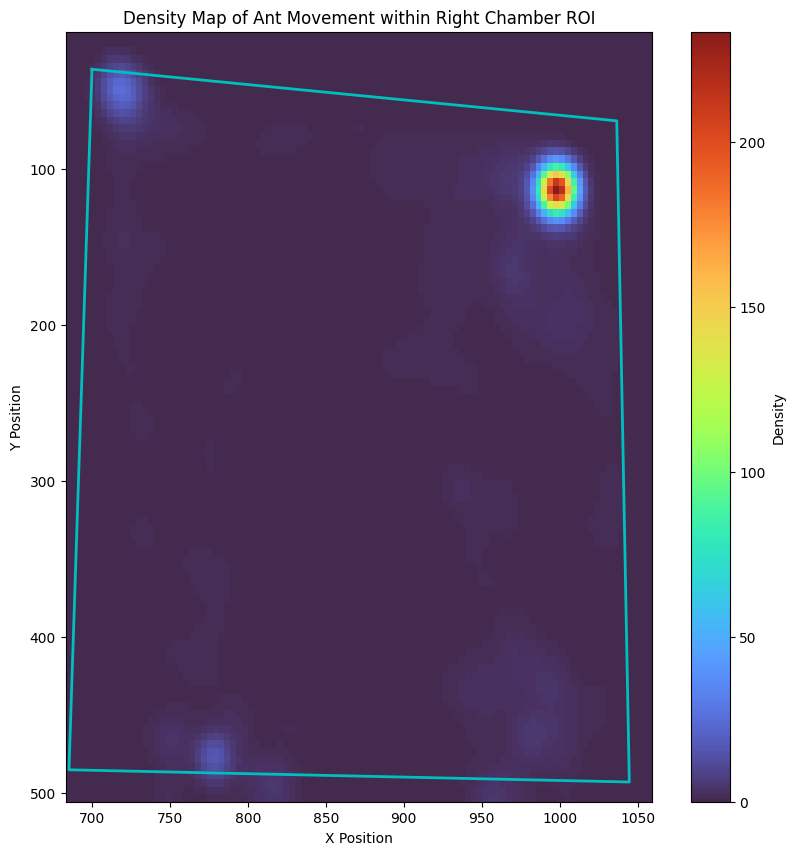

In [ ]:
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

# Assuming the 'extract_corner_points_over_frames' function is already defined
# Assuming df, scorer, corner_names, corner_order are already defined and loaded

# Extract corner points for the entire DataFrame
corner_points = extract_corner_points_over_frames(df, scorer, corner_names)

# Extract positions for both ants and filter out NaN values
all_ants_x, all_ants_y = [], []

for ant in ants:
    ant_full_x = df[(scorer, ant, tracked_keypoint_name, 'x')].values
    ant_full_y = df[(scorer, ant, tracked_keypoint_name, 'y')].values
    valid_indices = ~np.isnan(ant_full_x) & ~np.isnan(ant_full_y)
    all_ants_x.extend(ant_full_x[valid_indices])
    all_ants_y.extend(ant_full_y[valid_indices])

# Create a combined 2D histogram for the "super ant"
grid_size = 100  # Adjust for resolution
heatmap, xedges, yedges = np.histogram2d(all_ants_x, all_ants_y, bins=grid_size, range=[[xmin, xmax], [ymin, ymax]])

# Apply Gaussian smoothing
heatmap_smoothed = gaussian_filter(heatmap, sigma=2)

# Plotting the density map with an adjusted aspect ratio
plt.figure(figsize=(19.2, 10.8))  # This will create a figure with the aspect ratio of the video
plt.imshow(heatmap_smoothed.T, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='turbo', aspect='equal', alpha=0.9)

# Overlay the rectangle defined by the corner points
rectangle_x = [corner_points[corner][0][0] for corner in corner_order]
rectangle_y = [corner_points[corner][0][1] for corner in corner_order]
plt.plot(rectangle_x, rectangle_y, 'c-', linewidth=2)  # Cyan lines to define the rectangle

# Setting the title with placeholders
plot_title = "Density Map of Ant Movement within Right Chamber ROI"
plt.title(plot_title)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.colorbar(label='Density')

plt.ylim(ymax, ymin)

# Adjust the figure size to match the video aspect ratio more closely
# This doesn't change the plot's aspect ratio but makes the figure window more visually accurate
video_aspect_ratio = 1920 / 1080
fig_aspect_ratio = video_aspect_ratio * (plt.gcf().get_size_inches()[1] / plt.gcf().get_size_inches()[0])
plt.gcf().set_size_inches(10, 10 / fig_aspect_ratio)



# Simple total distance traveled analysis:

In [ ]:
# Calculate the total distances moved by the ant within the ROI
total_distances = compute_total_distance(df, scorer, ants, corner_names, tracked_keypoint_name)

# Sum the distances moved by all ants to get a single value
total_distance_all_ants = sum(total_distances.values())

# Output the combined total distance
print(f"The ant moved a total distance of {total_distance_all_ants:.2f} units within the region of interest (ROI).")


The ant moved a total distance of 59733.19 units within the region of interest (ROI).
